<a href="https://colab.research.google.com/github/nazalnihad/Image_processing_lab/blob/main/set_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def motion_blur(image, size=15):
    kernel = np.zeros((size, size))
    kernel[int((size - 1)/2), :] = np.ones(size)
    kernel /= size
    return cv2.filter2D(image, -1, kernel), kernel

In [ ]:
def inverse_filtering(degraded, H):
    # DFT of degraded image
    G = np.fft.fft2(degraded)
    H_f = np.fft.fft2(H, s=degraded.shape)

    # Avoid divide by zero (add epsilon)
    epsilon = 1e-6
    F_hat = G / (H_f + epsilon)

    # Inverse DFT to get restored image
    f_restored = np.fft.ifft2(F_hat)
    f_restored = np.abs(f_restored)
    return np.uint8(np.clip(f_restored, 0, 255))

In [ ]:
# Load grayscale image
img = cv2.imread("bullet-space.jpg", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))

# Apply motion blur (degradation)
degraded, kernel = motion_blur(img, size=15)

# Restore using inverse filtering
restored = inverse_filtering(degraded, kernel)



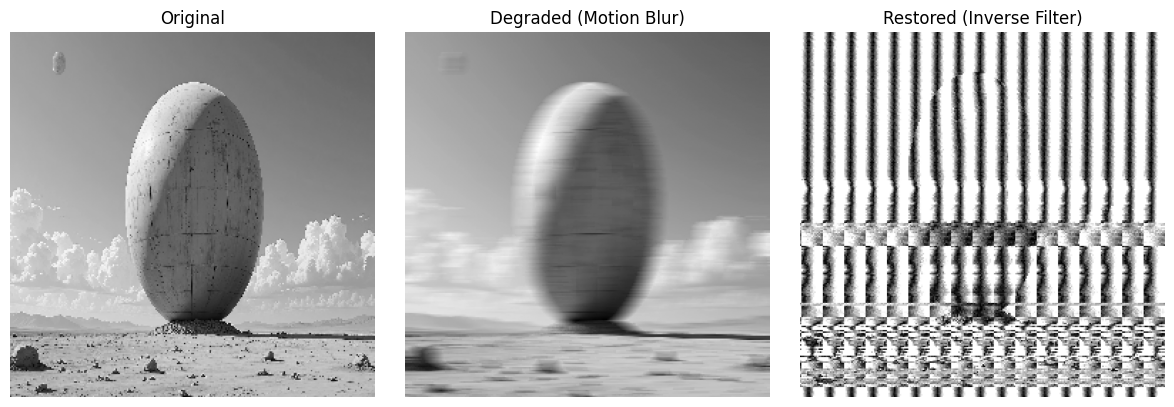

In [ ]:
titles = ["Original", "Degraded (Motion Blur)", "Restored (Inverse Filter)"]
images = [img, degraded, restored]

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Q2

In [ ]:
img = cv2.imread("bullet-space.jpg", cv2.IMREAD_GRAYSCALE)

In [ ]:
def motion_blur_psf(shape, a=0.1, b=0.1, T=1):
    M, N = shape
    U, V = np.meshgrid(np.arange(-N//2, N//2), np.arange(-M//2, M//2))
    H = T * (np.sinc(a*U + b*V) + 1e-8) * np.exp(-1j*np.pi*(a*U + b*V))
    return np.fft.ifftshift(H)

H = motion_blur_psf(img.shape)

In [ ]:
F = np.fft.fft2(img)

# Apply degradation
G = H * F

# Add Gaussian noise
noise = np.random.normal(0, 10, img.shape)
G_noisy = G + np.fft.fft2(noise)

# Degraded image
g = np.abs(np.fft.ifft2(G_noisy))

In [ ]:
K = 0.01  # constant ratio
H_conj = np.conj(H)
W_filter_const = (H_conj / (np.abs(H)**2 + K))
F_hat_const = W_filter_const * G_noisy
f_hat_const = np.abs(np.fft.ifft2(F_hat_const))

In [ ]:
S_gg = np.abs(G_noisy)**2
# Noise power spectrum (estimated from added noise)
S_nn = np.abs(np.fft.fft2(noise))**2

# Wiener filter using auto-correlation
W_filter_auto = (H_conj / (np.abs(H)**2 + (S_nn / (S_gg + 1e-8))))
F_hat_auto = W_filter_auto * G_noisy
f_hat_auto = np.abs(np.fft.ifft2(F_hat_auto))

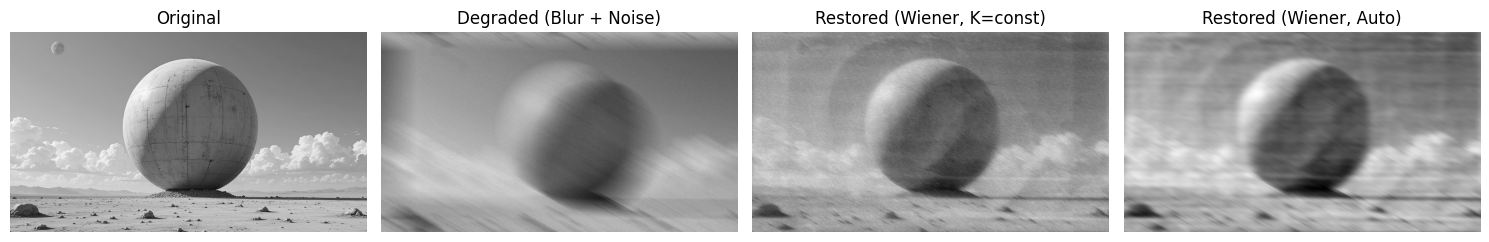

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(g, cmap='gray')
plt.title("Degraded (Blur + Noise)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(f_hat_const, cmap='gray')
plt.title("Restored (Wiener, K=const)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(f_hat_auto, cmap='gray')
plt.title("Restored (Wiener, Auto)")
plt.axis("off")

plt.tight_layout()
plt.show()

Q3

In [ ]:
def rgb_to_hsi(img):
    # Normalize RGB values to [0,1]
    img = img.astype(np.float32) / 255.0
    R, G, B = img[:, :, 2], img[:, :, 1], img[:, :, 0]

    # Intensity
    I = (R + G + B) / 3.0

    # Saturation
    min_val = np.minimum(np.minimum(R, G), B)
    S = 1 - (3 / (R + G + B + 1e-8)) * min_val  # avoid division by zero

    # Hue calculation
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G) ** 2 + (R - B) * (G - B)) + 1e-8
    theta = np.arccos(num / den)

    H = np.zeros_like(R)
    H[B <= G] = theta[B <= G]
    H[B > G] = (2 * np.pi - theta[B > G])

    H = H / (2 * np.pi)  # Normalize to [0,1]

    return H, S, I

In [ ]:
img = cv2.imread("bullet-space.jpg")  #

In [ ]:
H, S, I = rgb_to_hsi(img)

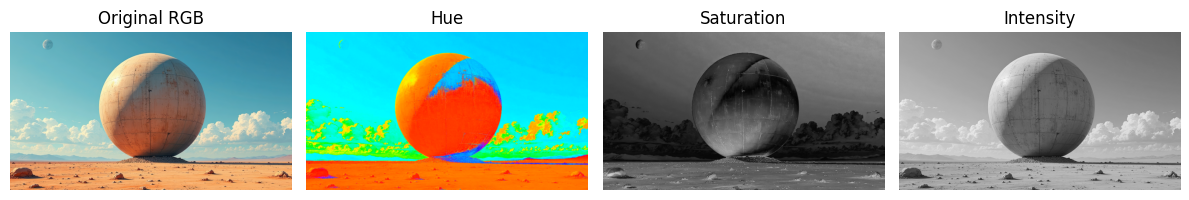

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(H, cmap="hsv")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(I, cmap="gray")
plt.title("Intensity")
plt.axis("off")

plt.tight_layout()
plt.show()

Q4

Q5

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

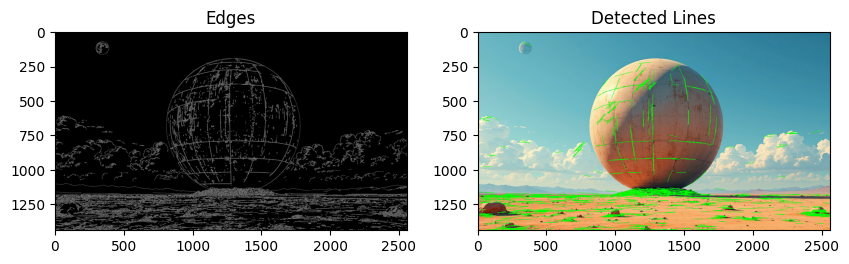

In [2]:
img = cv2.imread('bullet-space.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 50, 150)

lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=50, maxLineGap=10)

for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(edges, cmap='gray'); plt.title("Edges")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Detected Lines")
plt.show()

Q6

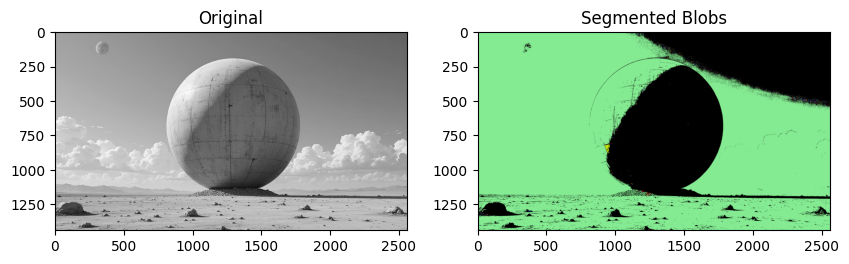

In [3]:
img = cv2.imread('bullet-space.jpg', cv2.IMREAD_GRAYSCALE)

_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

num_labels, labels = cv2.connectedComponents(thresh)

output = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
for i in range(1, num_labels):
    output[labels == i] = np.random.randint(0, 255, 3)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(output); plt.title("Segmented Blobs")
plt.show()

Q7

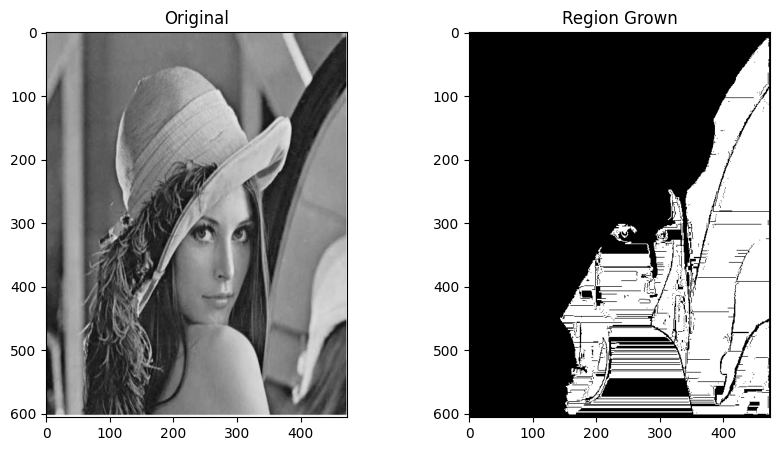

In [11]:
def region_growing(img, seed, threshold=10):
    visited = np.zeros_like(img, dtype=bool)
    region = np.zeros_like(img, dtype=np.uint8)
    h, w = img.shape
    mean_intensity = int(img[seed])
    stack = [seed]

    while stack:
        x, y = stack.pop()
        if visited[x, y]:
            continue
        visited[x, y] = True

        if abs(int(img[x, y]) - mean_intensity) < threshold:
            region[x, y] = 255
            mean_intensity = (mean_intensity + int(img[x, y])) // 2
            for dx, dy in [(-1,0),(1,0),(0,-1),(0,1)]:
                nx, ny = x+dx, y+dy
                if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                    stack.append((nx, ny))
    return region

seed_point = (img.shape[0]//2, img.shape[1]//2)
seg = region_growing(img, seed_point, threshold=15)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(seg, cmap='gray'); plt.title("Region Grown")
plt.show()

Q8

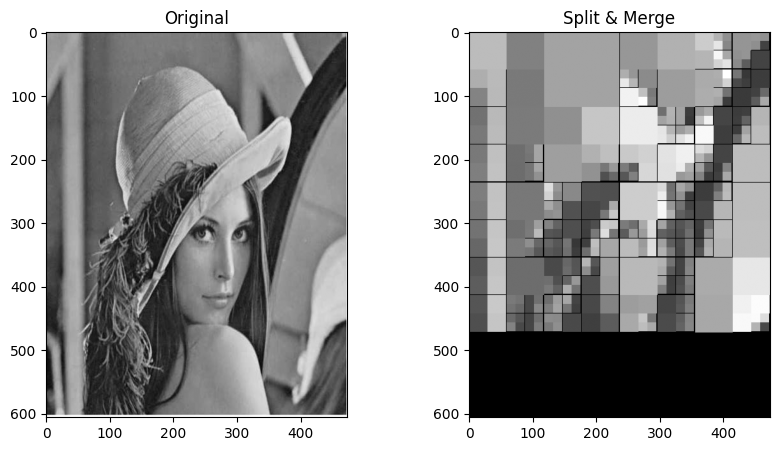

In [18]:
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)

def split_and_merge(img, min_size=32, var_threshold=500):
    h, w = img.shape
    result = np.zeros_like(img)

    def split(x, y, size):
        region = img[x:x+size, y:y+size]
        if size <= min_size or np.var(region) < var_threshold:
            mean_val = int(np.mean(region))
            result[x:x+size, y:y+size] = mean_val
        else:
            half = size // 2
            split(x, y, half)
            split(x, y+half, half)
            split(x+half, y, half)
            split(x+half, y+half, half)

    split(0, 0, min(h, w))
    return result

seg_img = split_and_merge(img, min_size=16, var_threshold=800)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(seg_img, cmap='gray'); plt.title("Split & Merge")
plt.show()


Q9

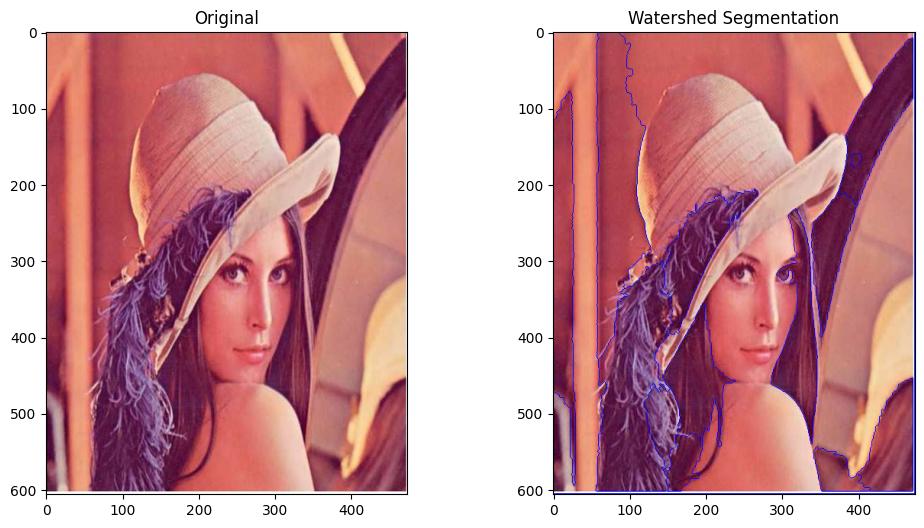

In [20]:
img = cv2.imread("lena.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Threshold
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Distance transform and sure foreground
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5*dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Unknown region
sure_bg = cv2.dilate(thresh, np.ones((3,3), np.uint8), iterations=3)
unknown = cv2.subtract(sure_bg, sure_fg)

# Markers for watershed
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed
img_ws = img.copy()
cv2.watershed(img_ws, markers)
img_ws[markers == -1] = [255, 0, 0]

# Display
plt.figure(figsize=(12,6))
plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(img_ws, cv2.COLOR_BGR2RGB)); plt.title("Watershed Segmentation")
plt.show()


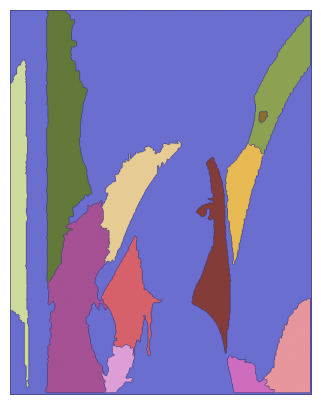

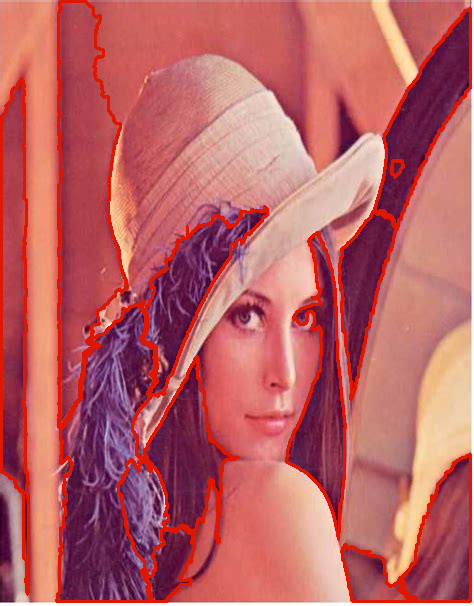

In [26]:
from google.colab.patches import cv2_imshow
# watershed Algorithm
markers = cv2.watershed(img, markers)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(markers, cmap="tab20b")
ax.axis('off')
plt.show()


labels = np.unique(markers)

coins = []
for label in labels[2:]:

# Create a binary image in which only the area of the label is in the foreground
#and the rest of the image is in the background
    target = np.where(markers == label, 255, 0).astype(np.uint8)

  # Perform contour extraction on the created binary image
    contours, hierarchy = cv2.findContours(
        target, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    coins.append(contours[0])

# Draw the outline
img = cv2.drawContours(img, coins, -1, color=(0, 23, 223), thickness=2)
cv2_imshow(img)